In [ ]:
%pip install --upgrade pip -q
%pip install opencv-python-headless -q
%pip install -U "albumentations>=1.3.0" -q

In [16]:
# Image Augmentation — Demo Per Transformasi pada Subset Training
import os, random, cv2
import matplotlib.pyplot as plt
import albumentations as A

# === Path dataset (hanya subset training) ===
base_train = os.path.join("..", "dataset", "raw", "_merged_resized")
images_dir = os.path.join(base_train, "images")
labels_dir = os.path.join(base_train, "labels")  # tidak dipakai di demo visual, tetapi ada untuk konteks YOLO

# === Validasi folder ===
if not os.path.isdir(images_dir):
    raise FileNotFoundError(f"Folder gambar tidak ditemukan: {images_dir}")

# === Ambil 1 gambar sampel secara acak dari training ===
samples = [f for f in os.listdir(images_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
if not samples:
    raise RuntimeError("Tidak ada file gambar pada dataset/processed/train/images.")

sample_name = "WhatsApp-Image-2025-09-29-at-17_28_35_jpeg.rf.2571a51334ce36eadb3b09a5ce40aa89.jpg"
img_path = os.path.join(images_dir, sample_name)

# === Muat gambar (cv2 -> BGR ke RGB untuk matplotlib) ===
image_bgr = cv2.imread(img_path)
if image_bgr is None:
    raise RuntimeError(f"Gagal memuat gambar: {img_path}")
real_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Gambar sampel: {sample_name} | Ukuran: {real_image.shape[1]}×{real_image.shape[0]}")

# === Fungsi bantu untuk menampilkan hasil sebelum–sesudah ===
def show_comparison(real_image, aug_image):
    """Menampilkan gambar asli dan hasil augmentasi secara berdampingan."""
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=120)
    for ax, img, lbl in zip(axes, [real_image, aug_image], ["Sebelum", "Sesudah"]):
        ax.imshow(img)
        ax.set_title(lbl, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Gambar sampel: WhatsApp-Image-2025-09-29-at-17_28_35_jpeg.rf.2571a51334ce36eadb3b09a5ce40aa89.jpg | Ukuran: 640×640


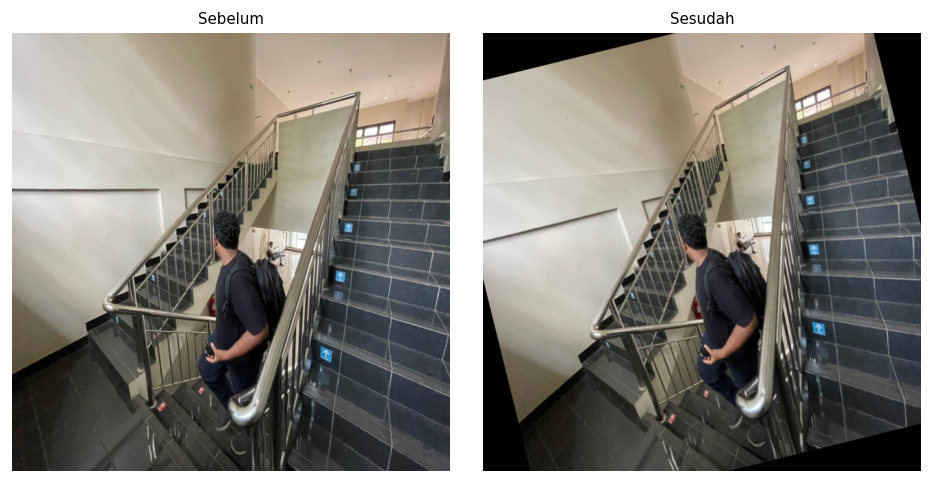

In [22]:
# Rotasi digunakan untuk menambah variasi orientasi objek agar model tidak bias terhadap arah tertentu.
rotation_tf = A.Rotate(limit=20, border_mode=cv2.BORDER_CONSTANT, p=1.0)
aug_image = rotation_tf(image=real_image)["image"]
show_comparison(real_image, aug_image)

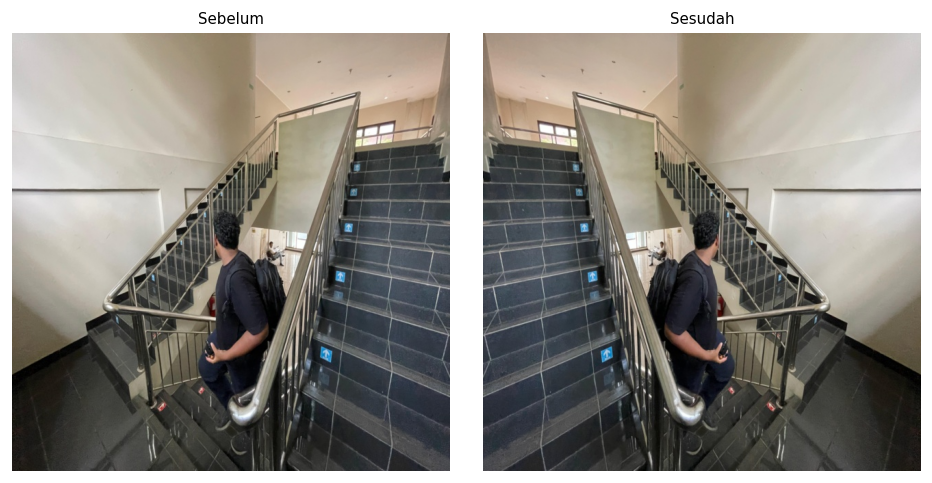

In [24]:
# Flipping horizontal membuat model mengenali objek dari sisi kiri maupun kanan.
flip_transform = A.HorizontalFlip(p=1.0)
aug_image = flip_transform(image=real_image)["image"]
show_comparison(real_image, aug_image)

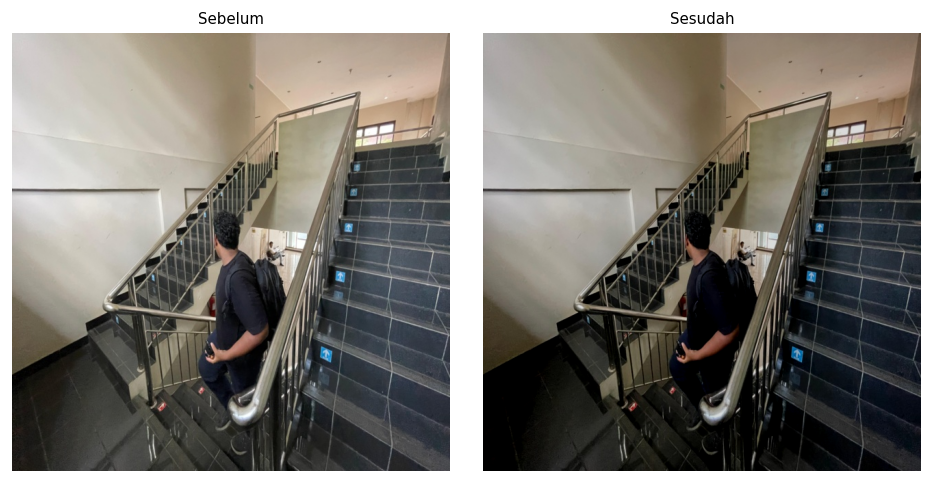

In [52]:
# Penyesuaian kecerahan meniru variasi kondisi pencahayaan (lebih terang/redup).
brightness_transform = A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.0, p=1.0)
aug_image = brightness_transform(image=real_image)["image"]
show_comparison(real_image, aug_image)

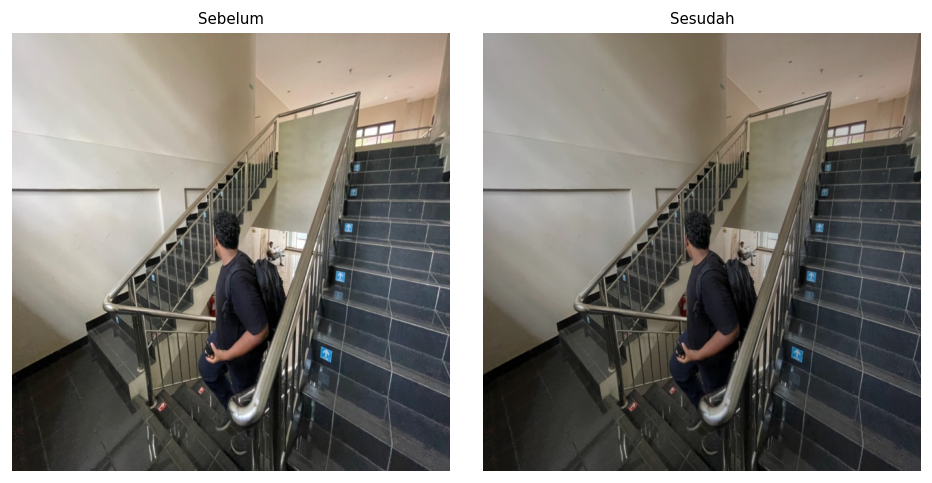

In [49]:
# Penyesuaian kontras membantu model stabil terhadap perbedaan kontras antar perangkat kamera.
contrast_transform = A.RandomBrightnessContrast(brightness_limit=0.0, contrast_limit=0.20, p=1.0)
aug_image = contrast_transform(image=real_image)["image"]
show_comparison(real_image, aug_image)

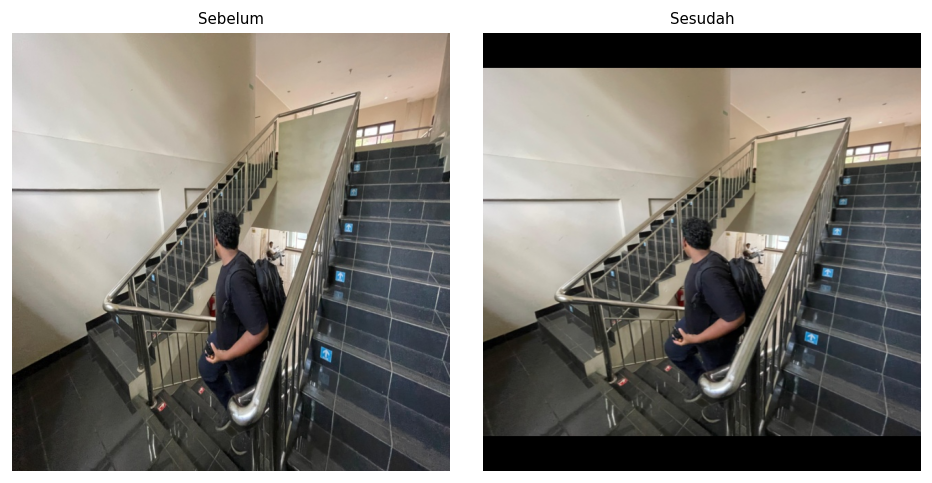

In [87]:
# Zoom in/out meniru perbedaan jarak kamera terhadap objek (skala tampilan).
zoom_transform = A.Affine(scale=(0.8, 1.2), p=1.0)
aug_image = zoom_transform(image=real_image)["image"]
show_comparison(real_image, aug_image)

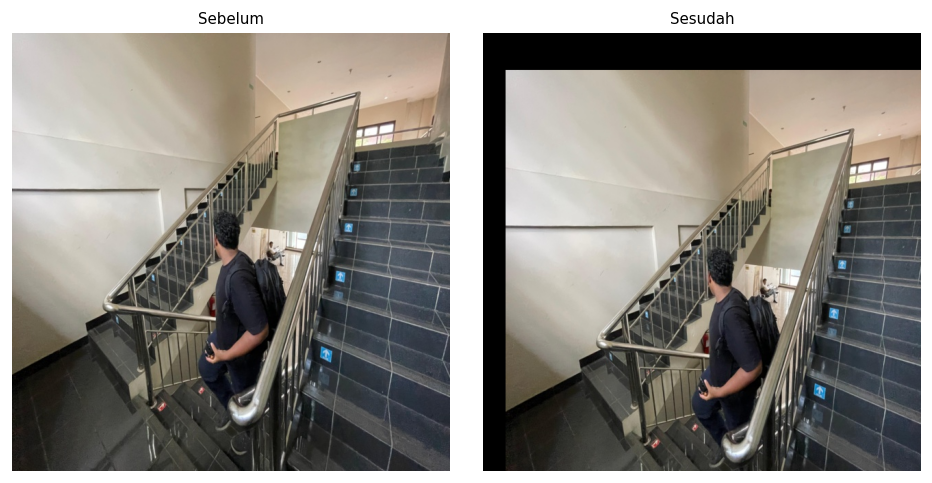

In [103]:
# Translasi meniru pergeseran posisi objek di dalam frame (kiri/kanan/atas/bawah).
translation_transform = A.Affine(translate_percent=(-0.1, 0.1), scale=1.0, p=1.0)
aug_image = translation_transform(image=real_image)["image"]
show_comparison(real_image, aug_image)